In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import re
import nupack
import biotite.structure.graphics as struc_graphics
from matplotlib.lines import Line2D
from biotite.application.viennarna import RNAplotApp

# ---------- 核心计算函数 ----------
def compute_tube_all_data(sequences, custom_names, temperature, conc_um, sodium_conc, magnesium_conc, max_size):
    concentration = conc_um * 1e-6
    model = nupack.Model(material='dna', celsius=temperature,
                         sodium=sodium_conc, magnesium=magnesium_conc)
    strands = [nupack.Strand(seq, name=name) for seq, name in zip(sequences, custom_names)]
    all_conc_dict = {s: concentration for s in strands}
    tube_all = nupack.Tube(strands=all_conc_dict,
                           complexes=nupack.SetSpec(max_size=max_size, include=[]),
                           name='TubeAll')
    results = nupack.tube_analysis(tubes=[tube_all], model=model, compute=['mfe', 'pairs'])
    tube_result = results[0] if isinstance(results, list) else results
    return tube_result, strands

def compute_secondary_structure_data(sequences, selected_indices, custom_names, temperature,
                                     conc_um, sodium_conc, magnesium_conc, max_size, threshold):
    concentration = conc_um * 1e-6
    model = nupack.Model(material='dna', celsius=temperature,
                         sodium=sodium_conc, magnesium=magnesium_conc)
    strands = [nupack.Strand(seq, name=name) for seq, name in zip(sequences, custom_names)]
    selected_strands = [strands[i] for i in selected_indices]
    selected_conc_dict = {s: concentration for s in selected_strands}
    complex_of_interest = nupack.Complex(selected_strands, name='SelectedComplex')
    tube_selected = nupack.Tube(strands=selected_conc_dict,
                                complexes=nupack.SetSpec(max_size=max_size, include=[]),
                                name='TubeSelected')
    results = nupack.tube_analysis(tubes=[tube_selected], model=model, compute=['mfe', 'pairs'])
    tube_selected_result = results[0] if isinstance(results, list) else results
    comp_res = tube_selected_result[complex_of_interest]
    prob_mat = comp_res.pairs.to_array()
    N = prob_mat.shape[0]
    strand_order = complex_of_interest.strands
    local_lengths = [len(s) for s in strand_order]
    cum_idx = np.cumsum([0] + local_lengths)
    base_pairs = []
    pair_probs = []
    for i in range(N):
        for j in range(i+1, N):
            prob = prob_mat[i, j]
            if prob > threshold:
                base_pairs.append([i, j])
                pair_probs.append(prob)
    base_pairs = np.array(base_pairs)
    pair_probs = np.array(pair_probs)
    if base_pairs.size == 0:
        base_pairs = np.empty((0, 2), dtype=int)
    return {
        'prob_mat': prob_mat,
        'strand_order': strand_order,
        'local_lengths': local_lengths,
        'cum_idx': cum_idx,
        'base_pairs': base_pairs,
        'pair_probs': pair_probs,
        'strands': strands
    }

# ---------- 通用坐标获取函数 ----------
def get_secondary_structure_coords(base_labels, base_pairs, length, layout_type='radial'):
    layout_map = {
        'naview': RNAplotApp.Layout.NAVIEW,
        'radial': RNAplotApp.Layout.RADIAL,
        'circular': RNAplotApp.Layout.CIRCULAR,
        'rnaturtle': RNAplotApp.Layout.RNATURTLE,
        'rna_puzzler': RNAplotApp.Layout.RNAPUZZLER
    }
    current_layout = layout_map.get(layout_type, RNAplotApp.Layout.RADIAL)
    fig_temp, ax_temp = plt.subplots(figsize=(12, 8))
    struc_graphics.plot_nucleotide_secondary_structure(
        ax_temp,
        base_labels=base_labels,
        base_pairs=base_pairs,
        length=length,
        bond_linewidth=0,
        backbone_linewidth=0,
        layout_type=current_layout
    )
    if len(ax_temp.texts) >= length:
        positions = np.array([txt.get_position() for txt in ax_temp.texts[:length]])
    else:
        raise RuntimeError(f"临时绘图只生成了 {len(ax_temp.texts)} 个文本，预期 {length} 个。")
    plt.close(fig_temp)
    return positions

# ---------- 链着色图（带字母，无边框，无颜色条） ----------
def plot_chain_colored_structure(sequences, selected_indices, custom_names, temperature,
                                 conc_um, sodium_conc, magnesium_conc,
                                 max_size, threshold, layout_type='radial', free_energy=None):
    data = compute_secondary_structure_data(
        sequences, selected_indices, custom_names, temperature,
        conc_um, sodium_conc, magnesium_conc, max_size, threshold
    )
    prob_mat = data['prob_mat']
    strand_order = data['strand_order']
    local_lengths = data['local_lengths']
    cum_idx = data['cum_idx']
    base_pairs = data['base_pairs']
    strands_all = data['strands']
    N = prob_mat.shape[0]

    full_seq = ''.join([str(s).replace('U', 'T') for s in strand_order])
    base_labels = list(full_seq)

    positions = get_secondary_structure_coords(base_labels, base_pairs, N, layout_type)

    total_len = max(local_lengths)
    base_figsize = (16, 10)
    scale_factor = max(1.0, total_len / 30 - 0.6)
    figsize = (base_figsize[0] * scale_factor, base_figsize[1] * scale_factor)
    fig, ax = plt.subplots(figsize=figsize)
    point_size = max(40, 100 - total_len * 0.5)

    # 链颜色映射
    paired = plt.cm.Paired.colors
    light_colors = [paired[i * 2] for i in range(len(strands_all))]
    strand_color_dict = {strand: light_colors[i % len(light_colors)]
                         for i, strand in enumerate(strands_all)}

    # 主干线
    for strand_idx, start in enumerate(cum_idx[:-1]):
        end = cum_idx[strand_idx + 1]
        for i in range(start, end - 1):
            ax.plot([positions[i, 0], positions[i+1, 0]],
                    [positions[i, 1], positions[i+1, 1]],
                    color='black', linewidth=1, zorder=1, alpha=0.5)

    # 碱基点（按链着色，无黑色边框）
    chain_colors = []
    for strand_obj in strand_order:
        chain_colors.extend([strand_color_dict[strand_obj]] * len(strand_obj))
    ax.scatter(positions[:, 0], positions[:, 1],
               c=chain_colors, s=point_size, zorder=5, alpha=1, edgecolor='none')

    # 碱基标签（显示字母）
    label_fontsize = max(6, 9 - total_len // 30)
    for i, (x, y) in enumerate(positions):
        ax.text(x, y, full_seq[i], ha='center', va='center',
                fontsize=label_fontsize, fontweight='bold', color='black', alpha=1, zorder=6)

    # 5' 和 3' 标记
    marker_fontsize = 9
    for strand_idx, (start, length) in enumerate(zip(cum_idx[:-1], local_lengths)):
        x5, y5 = positions[start]
        ax.text(x5 - 1.5, y5 - 1.5, "5'", fontsize=marker_fontsize, fontweight='bold',
                ha='right', va='top', color='black', zorder=10)
        end_idx = start + length - 1
        x3, y3 = positions[end_idx]
        ax.text(x3 + 1.5, y3 + 1.5, "3'", fontsize=marker_fontsize, fontweight='bold',
                ha='left', va='bottom', color='black', zorder=10)

    # 配对连线（统一灰色）
    if len(base_pairs) > 0:
        for (i, j) in base_pairs:
            ax.plot([positions[i, 0], positions[j, 0]],
                    [positions[i, 1], positions[j, 1]],
                    color='gray', linewidth=3, alpha=0.8, zorder=2)
    else:
        print("注意：未发现高于阈值的碱基对，图中无连线。")

    # 链图例
    legend_elements = []
    for strand_obj in strand_order:
        color = strand_color_dict[strand_obj]
        legend_elements.append(
            Line2D([0], [0], marker='o', color='w', label=strand_obj.name,
                   markerfacecolor=color, alpha=1, markersize=10, markeredgecolor='black')
        )
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.9, 1.1),
              fontsize=10, frameon=True)

    ax.set_aspect('equal')
    ax.axis('off')
    title = f'Chain-colored Secondary Structure (threshold = {threshold})'
    if free_energy is not None:
        title += f'  ΔG = {free_energy:.2f} kcal/mol'
    ax.set_title(title)
    plt.tight_layout()
    return fig

# ---------- 概率着色图（无字母，带颜色条，无边框） ----------
def plot_prob_colored_structure(sequences, selected_indices, custom_names, temperature,
                                conc_um, sodium_conc, magnesium_conc,
                                max_size, threshold, cmap_name='coolwarm',
                                layout_type='radial', free_energy=None):
    data = compute_secondary_structure_data(
        sequences, selected_indices, custom_names, temperature,
        conc_um, sodium_conc, magnesium_conc, max_size, threshold
    )
    prob_mat = data['prob_mat']
    strand_order = data['strand_order']
    local_lengths = data['local_lengths']
    cum_idx = data['cum_idx']
    base_pairs = data['base_pairs']
    pair_probs = data['pair_probs']   # 需要定义，用于配对碱基
    strands_all = data['strands']
    N = prob_mat.shape[0]

    full_seq = ''.join([str(s).replace('U', 'T') for s in strand_order])
    base_labels = list(full_seq)

    positions = get_secondary_structure_coords(base_labels, base_pairs, N, layout_type)

    total_len = max(local_lengths)
    base_figsize = (16, 10)
    scale_factor = max(1.0, total_len / 30 - 0.6)
    figsize = (base_figsize[0] * scale_factor, base_figsize[1] * scale_factor)
    fig, ax = plt.subplots(figsize=figsize)
    point_size = max(40, 100 - total_len * 0.5)

    # 计算每个碱基的着色值：
    # - 配对碱基：使用配对概率（与伙伴结合的概率）
    # - 未配对碱基：使用未配对概率（prob_mat[i,i]）
    color_val = [prob_mat[i, i] for i in range(N)]  # 初始为未配对概率
    for (i, j), prob in zip(base_pairs, pair_probs):
        # 若同一碱基出现在多个配对中，取最大概率（更显著）
        color_val[i] = max(color_val[i], prob)
        color_val[j] = max(color_val[j], prob)

    # 颜色映射
    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=1)
    base_colors = cmap(norm(color_val))

    # 主干线
    for strand_idx, start in enumerate(cum_idx[:-1]):
        end = cum_idx[strand_idx + 1]
        for i in range(start, end - 1):
            ax.plot([positions[i, 0], positions[i+1, 0]],
                    [positions[i, 1], positions[i+1, 1]],
                    color='black', linewidth=1, zorder=1, alpha=0.5)

    # 碱基点（无黑色边框）
    ax.scatter(positions[:, 0], positions[:, 1],
               c=base_colors, s=point_size, zorder=5, alpha=1, edgecolor='none')

    # 无碱基标签
    # 5' 和 3' 标记
    marker_fontsize = 9
    for strand_idx, (start, length) in enumerate(zip(cum_idx[:-1], local_lengths)):
        x5, y5 = positions[start]
        ax.text(x5 - 1.5, y5 - 1.5, "5'", fontsize=marker_fontsize, fontweight='bold',
                ha='right', va='top', color='black', zorder=10)
        end_idx = start + length - 1
        x3, y3 = positions[end_idx]
        ax.text(x3 + 1.5, y3 + 1.5, "3'", fontsize=marker_fontsize, fontweight='bold',
                ha='left', va='bottom', color='black', zorder=10)

    # 配对连线（统一灰色）
    if len(base_pairs) > 0:
        for (i, j) in base_pairs:
            ax.plot([positions[i, 0], positions[j, 0]],
                    [positions[i, 1], positions[j, 1]],
                    color='gray', linewidth=3, alpha=0.8, zorder=2)
    else:
        print("注意：未发现高于阈值的碱基对，图中无连线。")

    # 颜色条
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(color_val)
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
    cbar.set_label('Stability Probability (paired/unpaired)')

    ax.set_aspect('equal')
    ax.axis('off')
    title = f'Probability-colored Secondary Structure (threshold = {threshold})'
    if free_energy is not None:
        title += f'  ΔG = {free_energy:.2f} kcal/mol'
    ax.set_title(title)
    plt.tight_layout()
    return fig

In [ ]:
# ---------- UI 控件 ----------
seq_input = mo.ui.text_area(
    value="CCCGCAGACACCTTCTCGACTCACTCAGAAGGTGTCTGCGGGAGTCG\nCGACTCCCGCAGACACCTTCT\nCGACTCCCGCAGACACCTTCTTCTGCGGGAGTCGAGAAGGTG\nTTTTTTTTTTTTTTTTTTT",
    label="序列列表（每行一条链，5'→3'）",
    rows=10
)

name_input = mo.ui.text_area(
    value="",
    label="链名称（可选，每行一个，对应上方序列）",
    rows=4,
    placeholder="留空则使用默认名称 Strand_i"
)

temp_slider = mo.ui.slider(20, 60, step=1, value=37, label="温度 (°C)")
conc_um = mo.ui.number(1.0, step=0.1, label="浓度 (μM)")
sodium = mo.ui.slider(0.05, 1.1, step=0.05, value=0.5, label="[Na+] (M)")
magnesium = mo.ui.slider(0.0, 0.2, step=0.005, value=0.01, label="[Mg2+] (M)")
max_size = mo.ui.slider(1, 10, step=1, value=3, label="复合物最多链数")
threshold = mo.ui.slider(0, 1, step=0.05, value=0.5, label="概率阈值")
layout_dropdown = mo.ui.dropdown(
    options=['naview', 'radial', 'circular', 'rnaturtle', 'rna_puzzler'],
    value='radial',
    label="布局算法"
)
cmap_dropdown = mo.ui.dropdown(
    options=['viridis', 'viridis_r', 'plasma', 'inferno', 'magma', 'cividis', 'RdBu', 'coolwarm'],
    value='coolwarm',
    label="颜色条"
)

run_button = mo.ui.run_button(label="运行分析")

mo.vstack([
    seq_input,
    name_input,
    temp_slider,
    conc_um,
    sodium,
    magnesium,
    max_size,
    threshold,
    layout_dropdown,
    cmap_dropdown,
    run_button
])

<marimo-text-area data-initial-value='"CCCGCAGACACCTTCTCGACTCACTCAGAAGGTGTCTGCGGGAGTCG\nCGACTCCCGCAGACACCTTCT\nCGACTCCCGCAGACACCTTCTTCTGCGGGAGTCGAGAAGGTG\nTTTTTTTTTTTTTTTTTTT"' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">序列列表（每行一条链，5'→3'）</span></span>"' data-placeholder='""' data-disabled='false' data-debounce='true' data-full-width='false' data-rows='10'>

<marimo-dropdown data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">选择复合物</span></span>"' data-options='["('(Strand_0+Strand_1+Strand_2) (0.37 μM)', '(Strand_0+Strand_1+Strand_2)')","('(Strand_0) (0.34 μM)', '(Strand_0)')","('(Strand_2) (0.29 μM)', '(Strand_2)')","('(Strand_3) (0.27 μM)', '(Strand_3)')","('(Strand_1+Strand_2) (0.24 μM)', '(Strand_1+Strand_2)')","('(Strand_1) (0.20 μM)', '(Strand_1)')","('(Strand_0+Strand_1) (0.18 μM)', '(Strand_0+Strand_1)')","('(Strand_3+Strand_3) (0.14 μM)', '(Strand_3+Strand_3)')","('(Strand_0+Strand_2) (0.09 μM)', '(Strand_0+Strand_2)')","('(Strand_3+Strand_3+Strand_3) (0.08 μM)', '(Strand_3+Strand_3+Strand_3)')","('(Strand_3+Strand_3+Strand_3+Strand_3) (0.05 μM)', '(Strand_3+Strand_3+Strand_3+Strand_3)')"]' data-allow-select-none='true' data-searchable='false' data-full-width='false'>
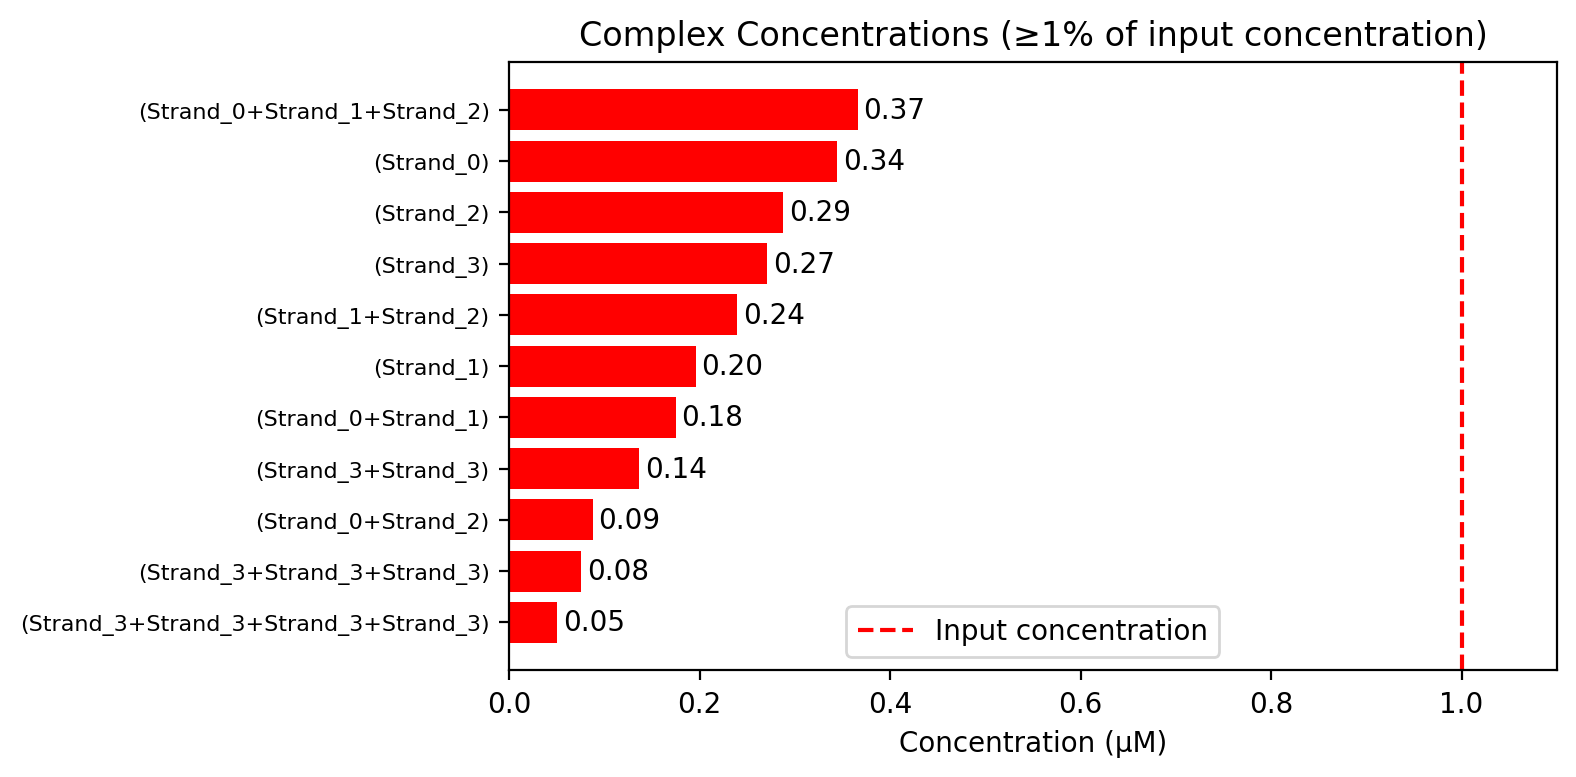

In [ ]:
# ---------- 单元格3：分析计算并显示柱状图、下拉框和“显示结构”按钮 ----------
def run_analysis():
    seqs = [s.strip() for s in seq_input.value.split('\n') if s.strip()]
    if not seqs:
        mo.warning("请至少输入一条序列")
        return None

    name_lines = [n.strip() for n in name_input.value.split('\n') if n.strip()]
    custom_names = []
    for i, seq in enumerate(seqs):
        if i < len(name_lines):
            custom_names.append(name_lines[i])
        else:
            custom_names.append(f"Strand_{i}")

    temp = temp_slider.value
    conc = conc_um.value
    sodium_val = sodium.value
    magnesium_val = magnesium.value
    max_sz = max_size.value
    thresh = threshold.value
    cmap_name = cmap_dropdown.value
    layout_choice = layout_dropdown.value

    tube_result, strands = compute_tube_all_data(
        seqs, custom_names, temp, conc, sodium_val, magnesium_val, max_sz
    )

    output_str = str(tube_result)
    if "Concentration results" not in output_str:
        mo.warning("未找到浓度结果")
        return None

    parts = output_str.split("Concentration results")
    if len(parts) <= 1:
        mo.warning("未找到浓度结果")
        return None

    conc_part = parts[1].strip()
    conc_lines = conc_part.split('\n')
    conc_lines = [line.strip() for line in conc_lines if line.strip()]
    if conc_lines and "Complex" in conc_lines[0]:
        conc_lines = conc_lines[1:]
    conc_lines = [line for line in conc_lines if not line.startswith('-') and line]

    pattern = re.compile(r'^(\(.+\))\s+([0-9.eE+-]+)')
    data = []
    for line in conc_lines:
        m = pattern.match(line)
        if m:
            name = m.group(1)
            conc_val = float(m.group(2))
            data.append((name, conc_val))

    if not data:
        mo.warning("无法解析浓度数据")
        return None

    threshold_conc = (conc * 1e-6) * 0.01
    filtered = [(name, c) for name, c in data if c >= threshold_conc]
    filtered.sort(key=lambda x: x[1], reverse=True)

    if not filtered:
        mo.warning("没有浓度达到阈值的复合物")
        return None

    # 构建选项列表
    options = [(f"{name} ({c*1e6:.2f} μM)", name) for name, c in filtered]

    # 绘制柱状图
    concs_um = [c * 1e6 for _, c in filtered]
    names = [n for n, _ in filtered]

    fig, ax = plt.subplots(figsize=(8, max(4, len(filtered)*0.3)))
    y_pos = range(len(names))
    bars = ax.barh(y_pos, concs_um, align='center', color='red')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Concentration (μM)')
    ax.set_title('Complex Concentrations (≥1% of input concentration)')
    ax.axvline(x=conc, color='red', linestyle='--', label='Input concentration')
    ax.bar_label(bars, fmt='%.2f', padding=2)
    ax.legend()
    max_conc = max(concs_um) if concs_um else 0
    ax.set_xlim(0, max(conc * 1.1, max_conc * 1.1))
    plt.tight_layout()

    return {
        'tube_result': tube_result,
        'strands': strands,
        'seqs': seqs,
        'custom_names': custom_names,
        'temp': temp,
        'conc': conc,
        'sodium_val': sodium_val,
        'magnesium_val': magnesium_val,
        'max_sz': max_sz,
        'thresh': thresh,
        'cmap_name': cmap_name,
        'layout_choice': layout_choice,
        'filtered': filtered,
        'bar_fig': fig,
        'options': options
    }

# 执行分析并显示结果
analysis_data = run_analysis()
bar_fig = analysis_data['bar_fig']
options = analysis_data['options']
complex_selector = mo.ui.dropdown(options=options, label="选择复合物")
show_button = mo.ui.run_button(label="显示结构")   # 使用 run_button，value 初始为0，点击后递增
mo.vstack([bar_fig, complex_selector, show_button])

In [ ]:
# ---------- 单元格4：响应“显示结构”按钮，同时显示两张图 ----------
fig_chain=None
fig_prob=None
if show_button.value and complex_selector.value:
    selected_name = complex_selector.value[1]
    print(f"正在查找复合物: '{selected_name}'")

    if 'analysis_data' not in globals() or analysis_data is None:
        mo.warning("尚未运行分析，请先点击“运行分析”按钮。")
    else:
        data = analysis_data
        tube_result = data['tube_result']
        strands = data['strands']
        seqs = data['seqs']
        custom_names = data['custom_names']
        temp = data['temp']
        conc = data['conc']
        sodium_val = data['sodium_val']
        magnesium_val = data['magnesium_val']
        max_sz = data['max_sz']
        thresh = data['thresh']
        cmap_name = data['cmap_name']
        layout_choice = data['layout_choice']

        # 解析选中的复合物名称中的链名列表
        match = re.match(r'\((.+)\)', selected_name)
        if match:
            inside = match.group(1)
            selected_strand_names = sorted([s.strip() for s in inside.split('+')])
        else:
            selected_strand_names = [selected_name.strip()]

        print(f"选中的链名列表: {selected_strand_names}")

        selected_complex = None
        for c in tube_result.complexes:
            c_strand_names = sorted([s.name for s in c.strands])
            if c_strand_names == selected_strand_names:
                selected_complex = c
                print("  匹配成功！")
                break

        if selected_complex is None:
            mo.warning(f"未找到复合物 {selected_name}")
        else:
            # 获取自由能
            fe = None
            if selected_complex in tube_result:
                comp_res = tube_result[selected_complex]
    # 尝试多种可能的属性名
                if hasattr(comp_res, 'mfe_structures') and comp_res.mfe_structures:
                    mfe_obj = comp_res.mfe_structures[0]
                    if hasattr(mfe_obj, 'free_energy'):
                        fe = mfe_obj.free_energy
                    elif hasattr(mfe_obj, 'energy'):
                        fe = mfe_obj.energy
                elif hasattr(comp_res, 'mfe') and comp_res.mfe:
                    mfe_obj = comp_res.mfe[0]
                    if hasattr(mfe_obj, 'free_energy'):
                        fe = mfe_obj.free_energy
                    elif hasattr(mfe_obj, 'energy'):
                        fe = mfe_obj.energy

            selected_indices = []
            for s in selected_complex.strands:
                for i, strand in enumerate(strands):
                    if strand.name == s.name:
                        selected_indices.append(i)
                        break
            if not selected_indices:
                mo.warning("无法提取链索引")
            else:
                # 生成链着色图
                fig_chain = plot_chain_colored_structure(
                    seqs, selected_indices, custom_names, temp, conc,
                    sodium_val, magnesium_val, max_sz, thresh,
                    layout_choice, free_energy=fe
                )
                # 生成概率着色图
                fig_prob = plot_prob_colored_structure(
                    seqs, selected_indices, custom_names, temp, conc,
                    sodium_val, magnesium_val, max_sz, thresh,
                    cmap_name, layout_choice, free_energy=fe
                )
                # 同时显示两张图
mo.vstack([fig_chain, fig_prob])

None None